# Exercise 3 — Choosing a readout strategy

*Covers notebook 03. Difficulty: ★★★☆☆*

Target: a SN Ia at $z=1.2$ (`x1=0`, `c=0`, at maximum). SNR is measured per resolution element,
in the rest-frame 4000–7000 Å range.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

In [2]:
snia = slicersim.LazuliSupernova(redshift=1.2)
snr_range = dict(lbda_range=[4000, 7000], frame="rest")

### 3.1 — Timing by hand

Compute by hand the total exposure time of 3 ramps in MACC(40, 8, 2), with
$t_\mathrm{frame}=2.83$ s. Check with slicersim.

In [3]:
n, m, d, nramps, tframe = 40, 8, 2, 3, 2.83
print("by hand  :", nramps * (n * (m + d) - d) * tframe)

snia.change_detector(nmd=(n, m, d), nramps=nramps)
print("slicersim:", snia.get_exposure_time())

by hand  : 3379.02
slicersim: 3379.0199999999995


### 3.2 — Effective readout noise

Write a function returning the effective readout noise of a ramp (Rauscher et al. 2007),
$\sigma_\mathrm{RON,eff} = \sigma_\mathrm{RON}\sqrt{12(n-1)/(m\,n\,(n+1))}$, and compare it with
`snia.simulation.detector.get_effective_ron(nmd=...)` for MACC(64, 8, 0), (16, 32, 0) and (64, 1, 0).

In [4]:
def effective_ron(n, m, ron=12):
    return ron * np.sqrt(12 * (n - 1) / (m * n * (n + 1)))

for nmd in [(64, 8, 0), (16, 32, 0), (64, 1, 0)]:
    print(nmd, f"{effective_ron(*nmd[:2]):.3f}", f"{snia.simulation.detector.get_effective_ron(nmd=nmd):.3f}")

(64, 8, 0) 1.809 1.809
(16, 32, 0) 1.726 1.726
(64, 1, 0) 5.116 5.116


### 3.3 — Same time, different strategies

You have ~48 min. Compare the SNR and the data volume of:
`(64, 8, 0)×2`, `(32, 8, 0)×4`, `(16, 8, 0)×8`, `(64, 16, 0)×1` and `(128, 8, 0)×1`.
Which one is best? Why are the last two not used in practice?

In [5]:
import pandas

rows = []
for nmd, nramps in [((64, 8, 0), 2), ((32, 8, 0), 4), ((16, 8, 0), 8), ((64, 16, 0), 1), ((128, 8, 0), 1)]:
    snia.change_detector(nmd=nmd, nramps=nramps)
    rows.append({"nmd": nmd, "nramps": nramps, "exptime [s]": snia.get_exposure_time(),
                 "SNR": snia.get_band_snr(**snr_range), "volume [GB]": snia.get_data_volume()})
pandas.DataFrame(rows).round(2)
# A single 48 min ramp is best (RON paid once), but such a long ramp is exposed to many
# cosmic rays and saturation; ramps are limited to max_group=64 groups.

,nmd,nramps,exptime [s],SNR,volume [GB]
0,"(64, 8, 0)",2,2897.92,6.32,4.29
1,"(32, 8, 0)",4,2897.92,4.79,4.29
2,"(16, 8, 0)",8,2897.92,2.92,4.29
3,"(64, 16, 0)",1,2897.92,7.01,2.15
4,"(128, 8, 0)",1,2897.92,7.01,4.29


### 3.4 — Impact of `max_group`

For `max_group` = 16, 32 and 64, find the configuration reaching SNR=10 with `setup_to_snr()`.
Plot the exposure time and the data volume as a function of `max_group`.

16 {'nmd': (16, 8, 0), 'nramps': 100}


32 {'nmd': (32, 8, 0), 'nramps': 19}
64 {'nmd': (64, 8, 0), 'nramps': 5}


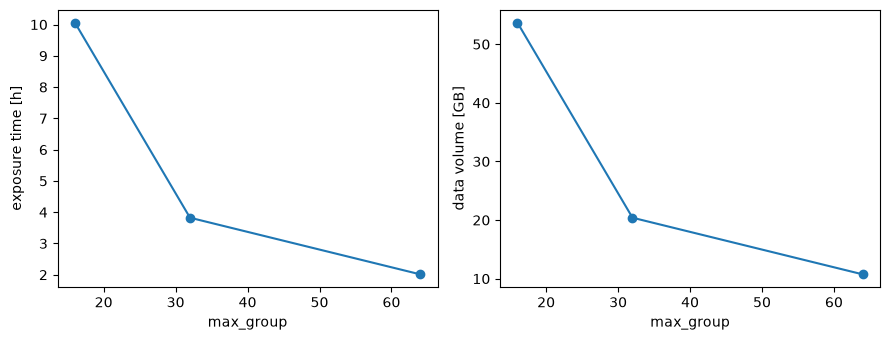

In [6]:
max_groups = [16, 32, 64]
exptimes, volumes = [], []
for max_group in max_groups:
    snia.change_detector(max_group=max_group)
    config, snr = snia.setup_to_snr(10, **snr_range)
    exptimes.append(snia.get_exposure_time() / 3600)
    volumes.append(snia.get_data_volume())
    print(max_group, config)

fig, (ax, ax_vol) = plt.subplots(1, 2, figsize=(9, 3.5))
ax.plot(max_groups, exptimes, "o-")
ax.set(xlabel="max_group", ylabel="exposure time [h]")
ax_vol.plot(max_groups, volumes, "o-")
ax_vol.set(xlabel="max_group", ylabel="data volume [GB]")
fig.tight_layout()
snia.change_detector(max_group=64)

### 3.5 — One ramp or several?

For target SNRs from 2 to 12, print the configuration chosen by `setup_to_snr()` (use
`inplace=False`). At which SNR does it switch to several ramps? Which frames-per-group values
does it use, and why?

In [7]:
for snr in range(2, 13, 2):
    config, reached = snia.setup_to_snr(snr, inplace=False, **snr_range)
    print(f"SNR={snr:2d} -> {config}  (reached {reached:.1f})")
# One ramp suffices while a full (64, 8, 0) ramp reaches the target; beyond, ramps are added.
# For bright targets (low SNR requirement here), fewer frames per group (m=4) are used to
# shorten the ramp while keeping enough groups.

SNR= 2 -> {'nmd': (32, 8, 0), 'nramps': 1}  (reached 2.4)


SNR= 4 -> {'nmd': (47, 8, 0), 'nramps': 1}  (reached 3.5)


SNR= 6 -> {'nmd': (64, 8, 0), 'nramps': 2}  (reached 6.3)


SNR= 8 -> {'nmd': (64, 8, 0), 'nramps': 3}  (reached 7.7)


SNR=10 -> {'nmd': (64, 8, 0), 'nramps': 5}  (reached 10.0)


SNR=12 -> {'nmd': (64, 8, 0), 'nramps': 7}  (reached 11.8)
